Load Data & Initial Inspection

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for professional plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load data (try tab delimiter)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv', delimiter='\t')

# Quick look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
if 'Attrition' in df.columns:
    print("\nTarget distribution:")
    print(df['Attrition'].value_counts())
    print(df['Attrition'].value_counts(normalize=True))

Shape: (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standard

In [ ]:
# This is a local notebook, no need to mount Google Drive

Mounted at /content/drive


In [13]:
df.tail()

,Age\tAttrition\tBusinessTravel\tDailyRate\tDepartment\tDistanceFromHome\tEducation\tEducationField\tEmployeeCount\tEmployeeNumber\tEnvironmentSatisfaction\tGender\tHourlyRate\tJobInvolvement\tJobLevel\tJobRole\tJobSatisfaction\tMaritalStatus\tMonthlyIncome\tMonthlyRate\tNumCompaniesWorked\tOver18\tOverTime\tPercentSalaryHike\tPerformanceRating\tRelationshipSatisfaction\tStandardHours\tStockOptionLevel\tTotalWorkingYears\tTrainingTimesLastYear\tWorkLifeBalance\tYearsAtCompany\tYearsInCurrentRole\tYearsSinceLastPromotion\tYearsWithCurrManager
1465,36\tNo\tTravel_Frequently\t884\tResearch & Dev...
1466,39\tNo\tTravel_Rarely\t613\tResearch & Develop...
1467,27\tNo\tTravel_Rarely\t155\tResearch & Develop...
1468,49\tNo\tTravel_Frequently\t1023\tSales\t2\t3\t...
1469,34\tNo\tTravel_Rarely\t628\tResearch & Develop...


Clean Useless Columns

In [7]:
# Columns to drop (constant or IDs)
constant_cols = ['EmployeeCount', 'StandardHours', 'Over18']
id_cols = ['EmployeeNumber']

# Only drop columns that exist
cols_to_drop = [col for col in constant_cols + id_cols if col in df.columns]
df_clean = df.drop(columns=cols_to_drop)
print(f"Removed {len(cols_to_drop)} columns. New shape: {df_clean.shape}")

Removed 4 columns. New shape: (1470, 31)


Understand Numerical & Categorical Features

In [6]:
# Split feature types
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Numerical features:", numerical_cols)
print("Categorical features:", categorical_cols)

Numerical features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical features: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\486273194.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()


Univariate Analysis (Single Features)

01) Target Variable (Attrition)

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\3087397697.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='Set2')


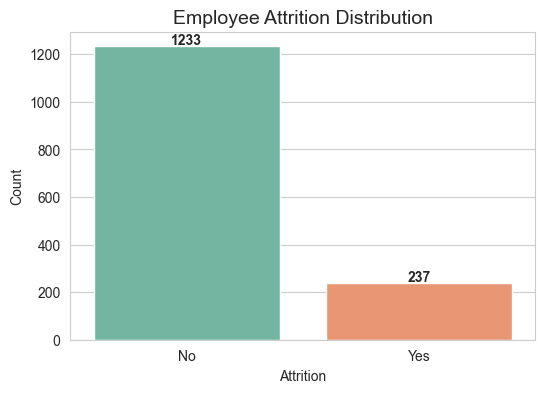

In [7]:
# Bar plot of Attrition
attrition_counts = df_clean['Attrition'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette='Set2')
plt.title('Employee Attrition Distribution', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Attrition')
for i, v in enumerate(attrition_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.savefig('attrition_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

2.Numerical Features – Distribution

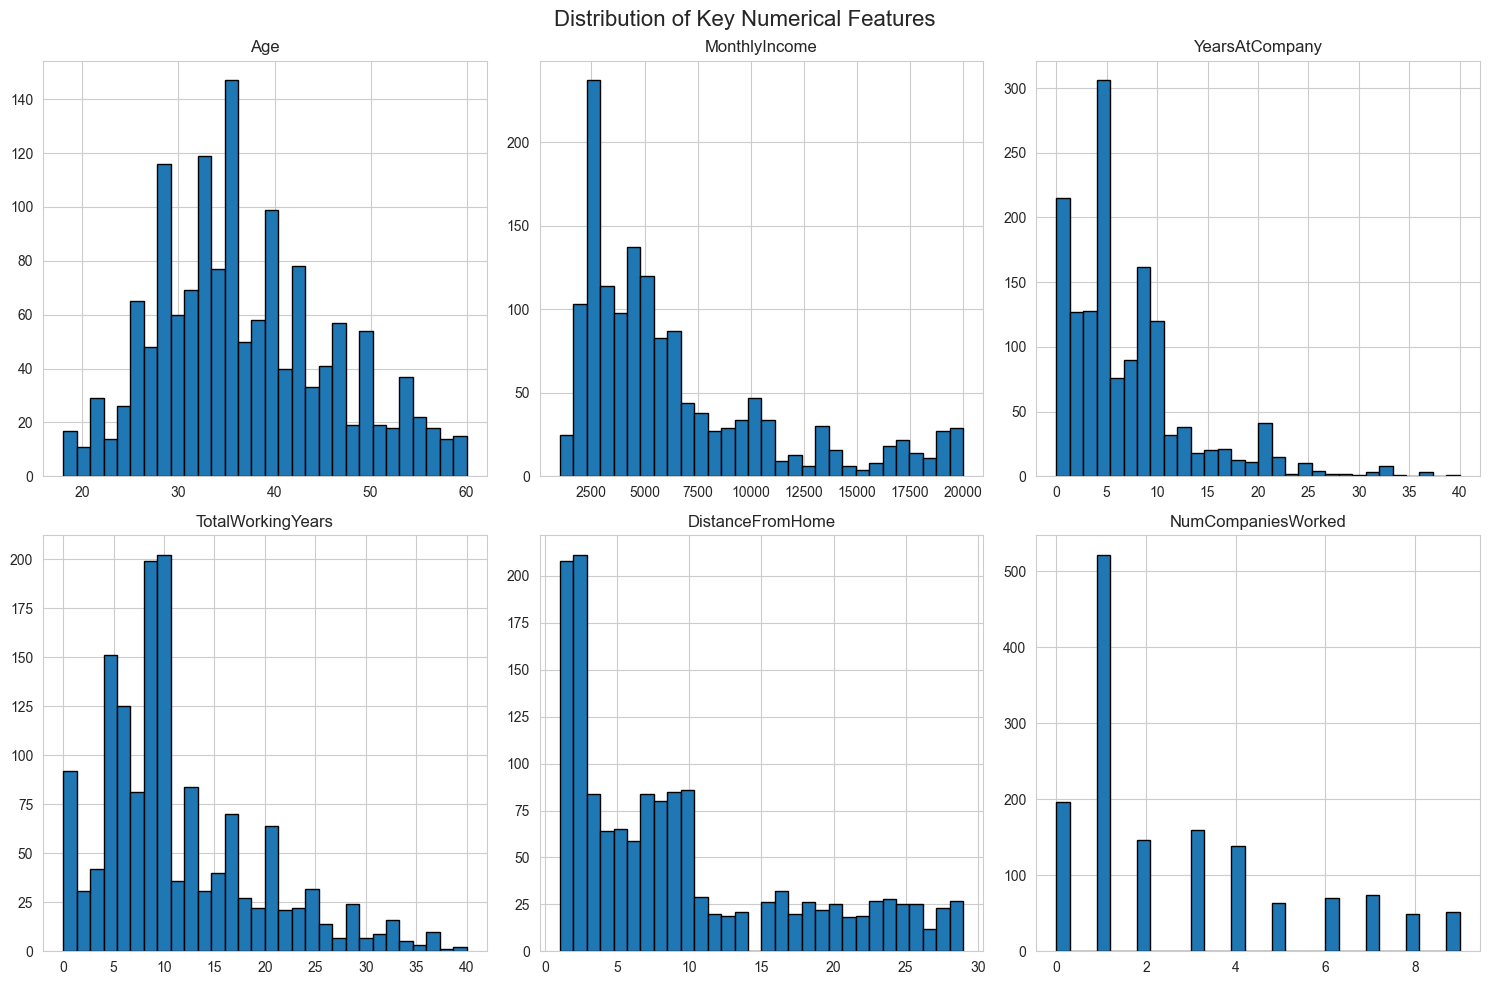

In [8]:
# Histograms with KDE
num_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears',
                'DistanceFromHome', 'NumCompaniesWorked']

df_clean[num_features].hist(bins=30, figsize=(15,10), layout=(2,3), edgecolor='black')
plt.suptitle('Distribution of Key Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=300)
plt.show()

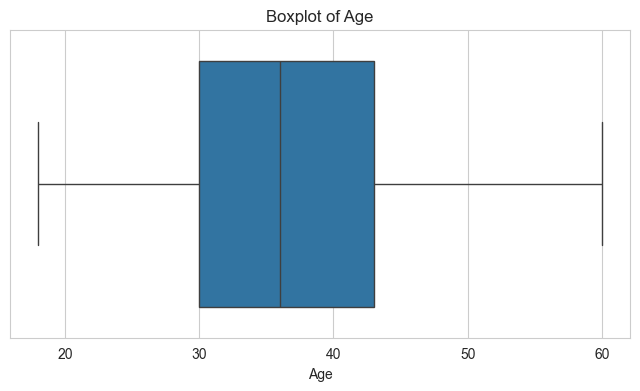

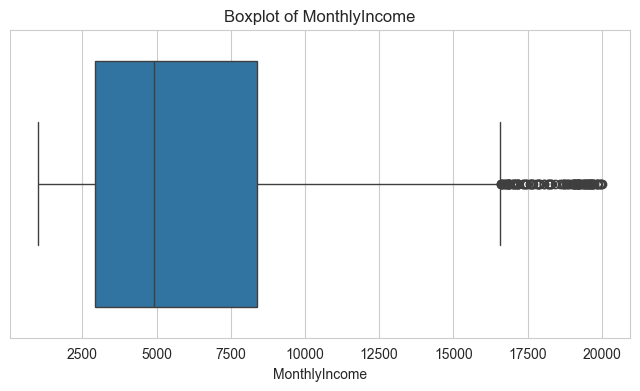

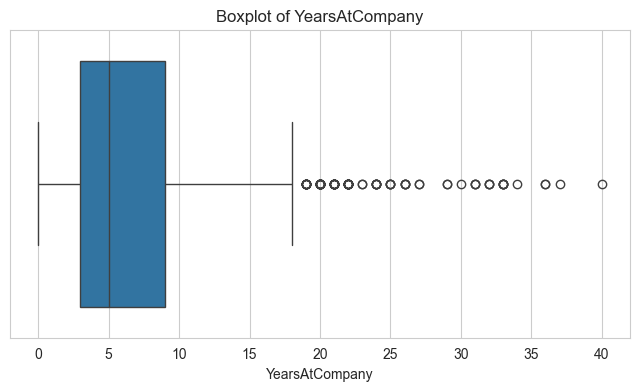

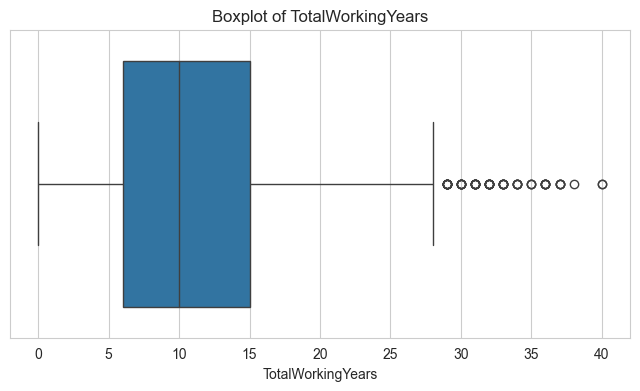

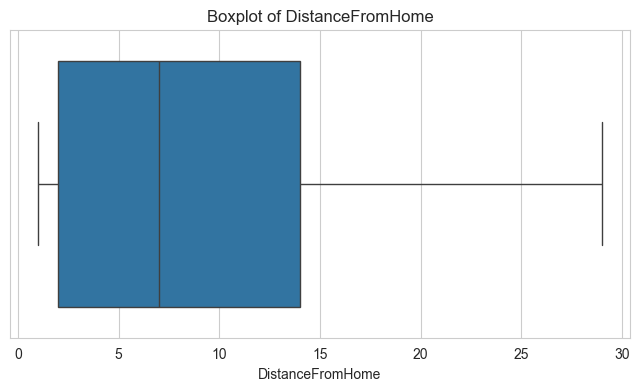

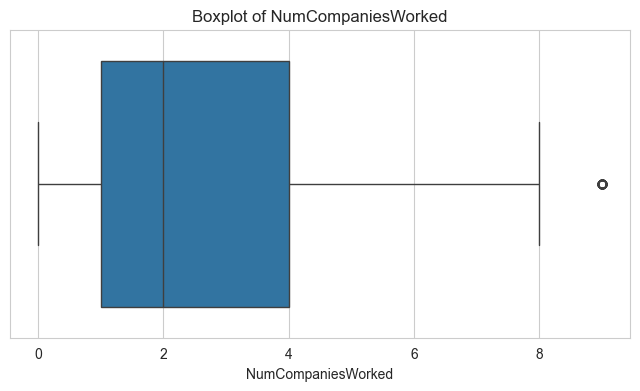

In [9]:
for col in num_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Categorical Features – Frequency

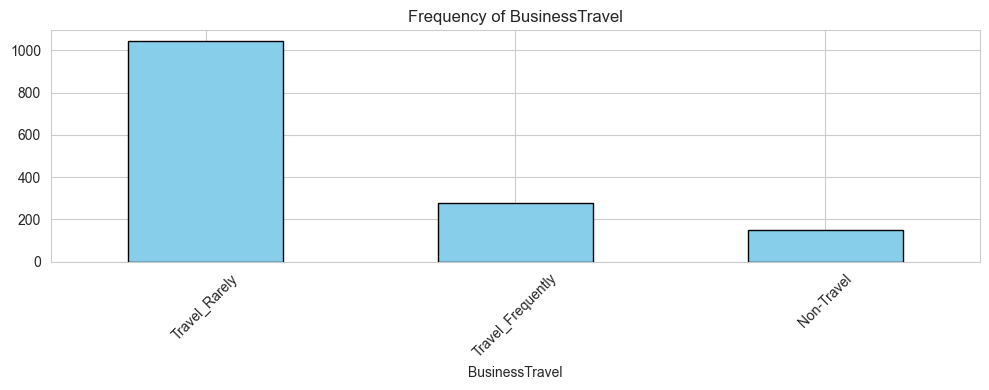

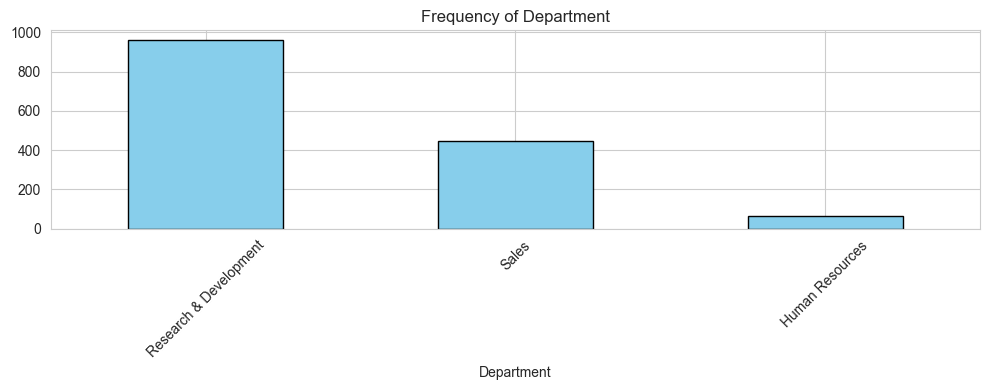

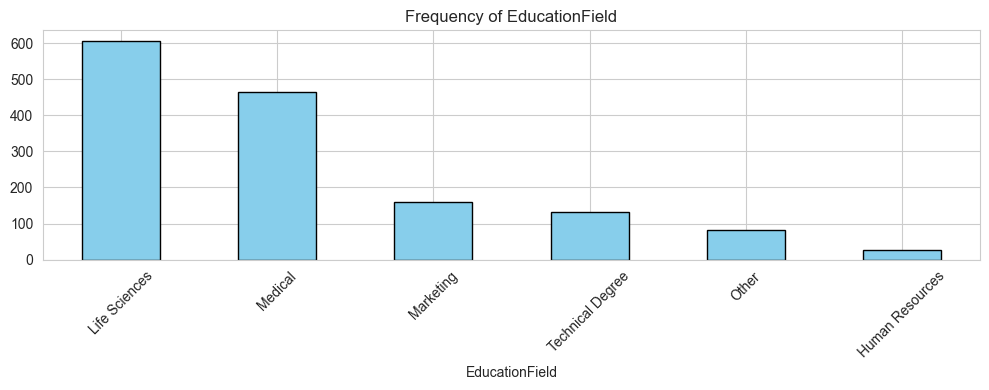

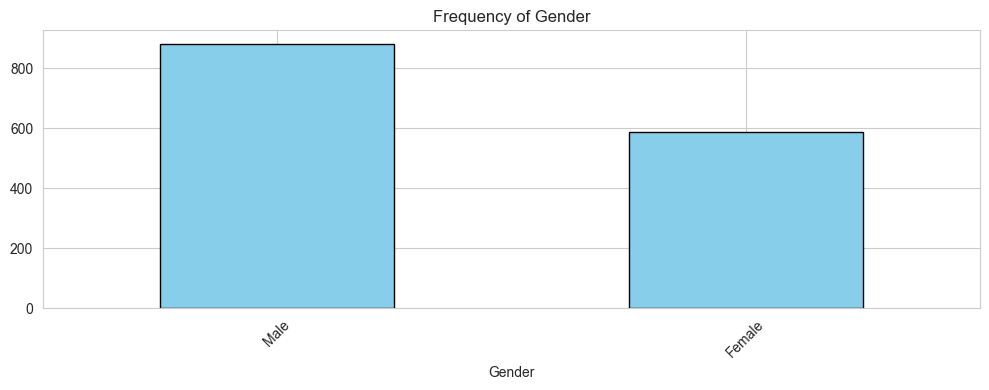

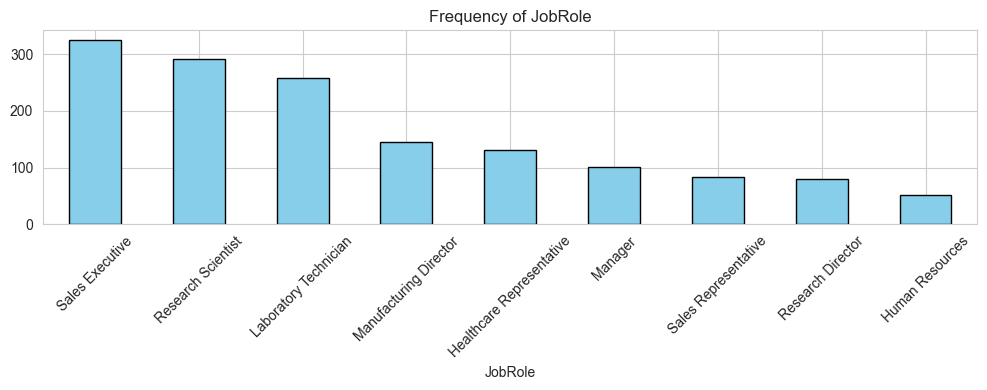

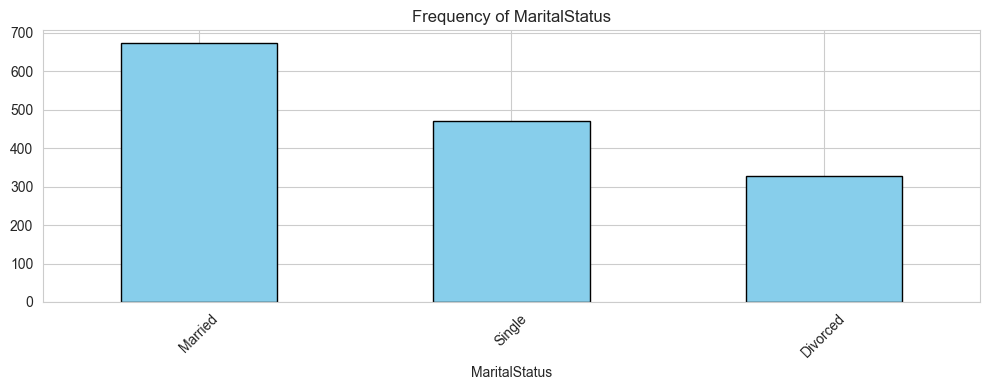

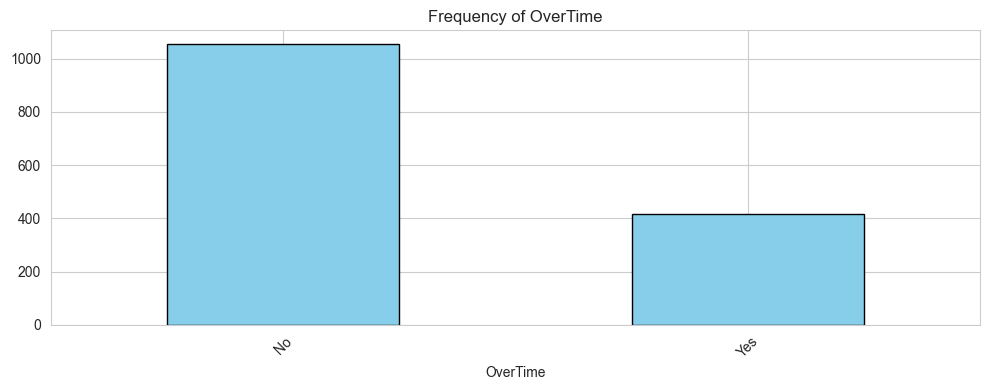

In [10]:
cat_features = ['BusinessTravel', 'Department', 'EducationField', 'Gender',
                'JobRole', 'MaritalStatus', 'OverTime']

for col in cat_features:
    plt.figure(figsize=(10,4))
    df_clean[col].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Bivariate Analysis (Features vs Attrition)

Numerical Features vs Attrition (Boxplots)

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


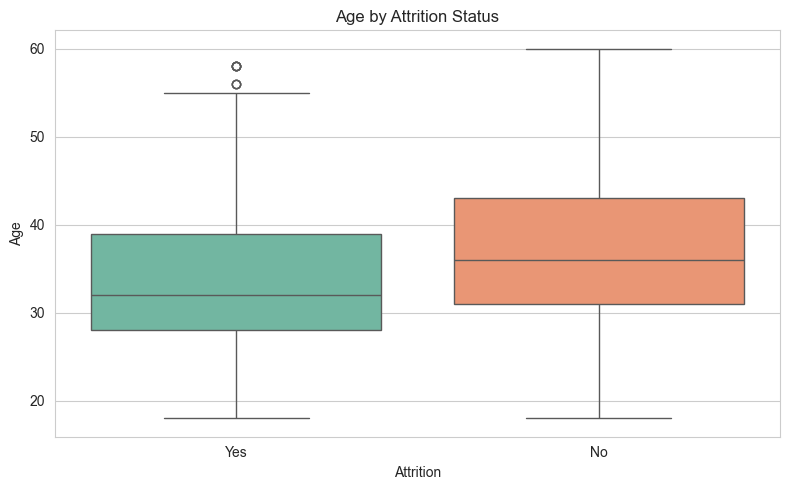

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


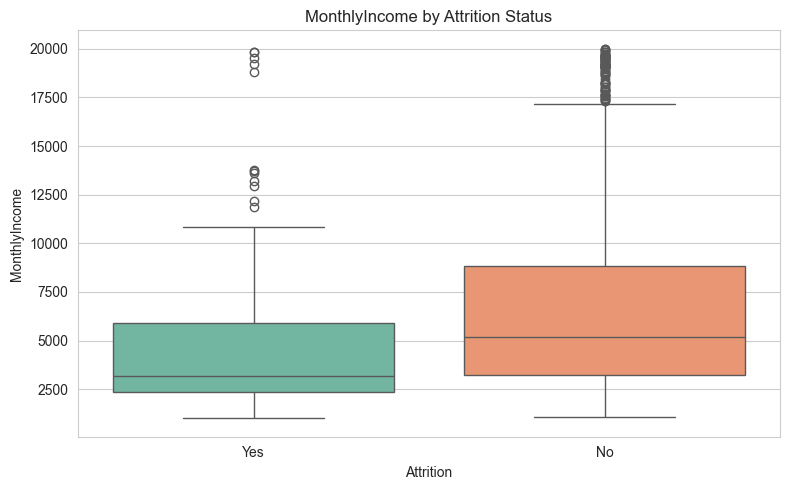

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


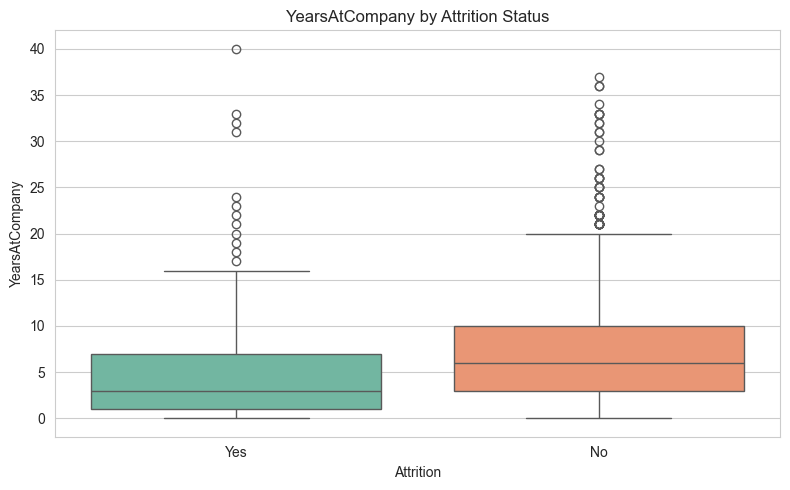

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


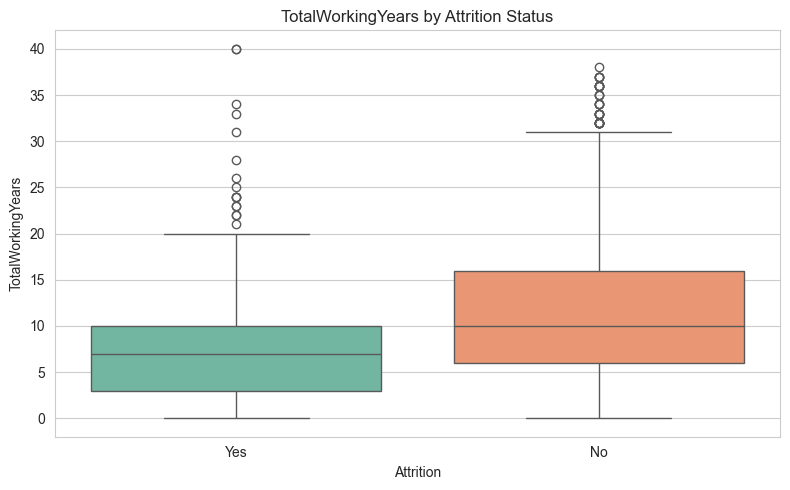

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


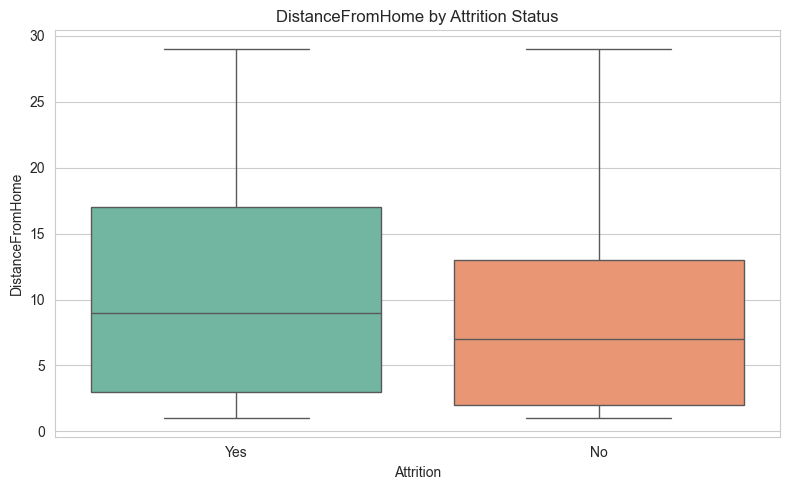

C:\Users\DELL\AppData\Local\Temp\ipykernel_22016\2183929891.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')


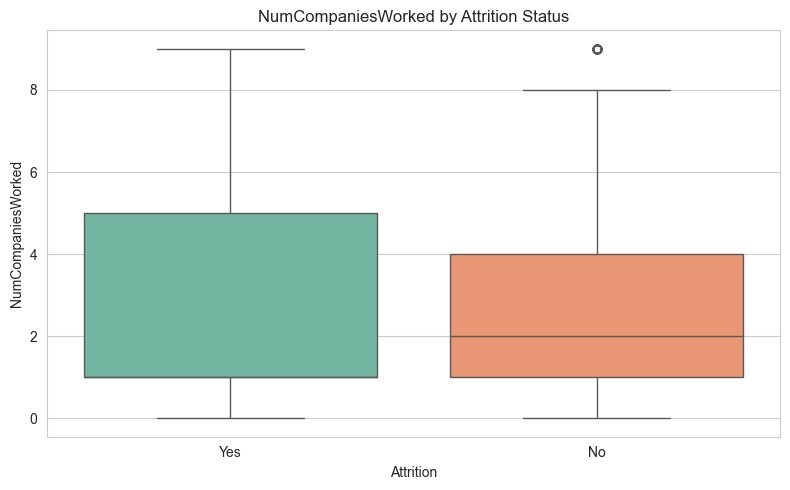

In [11]:
for col in num_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='Attrition', y=col, data=df_clean, palette='Set2')
    plt.title(f'{col} by Attrition Status')
    plt.tight_layout()
    plt.show()

Numerical Features vs Attrition (KDE plots)

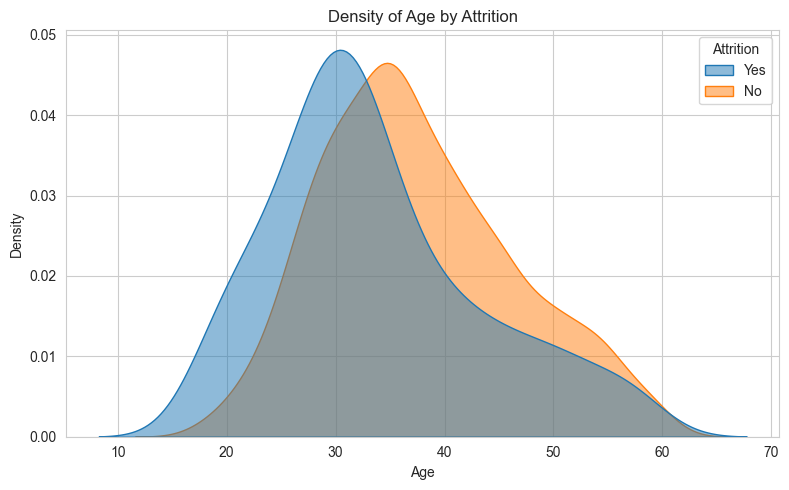

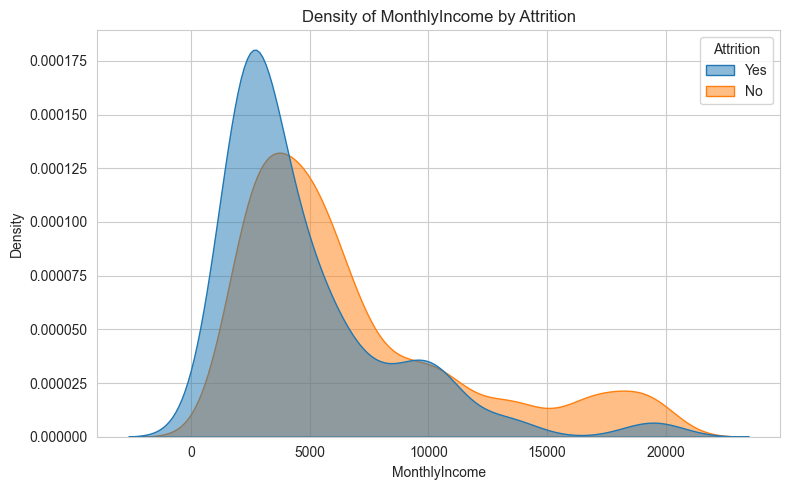

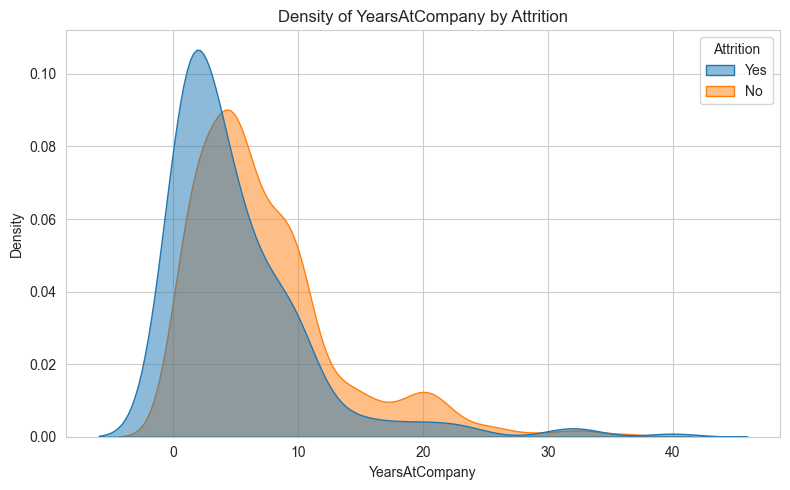

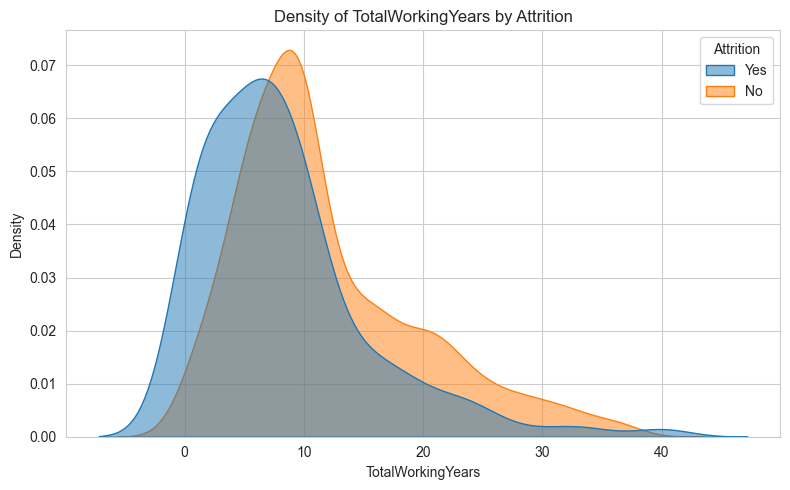

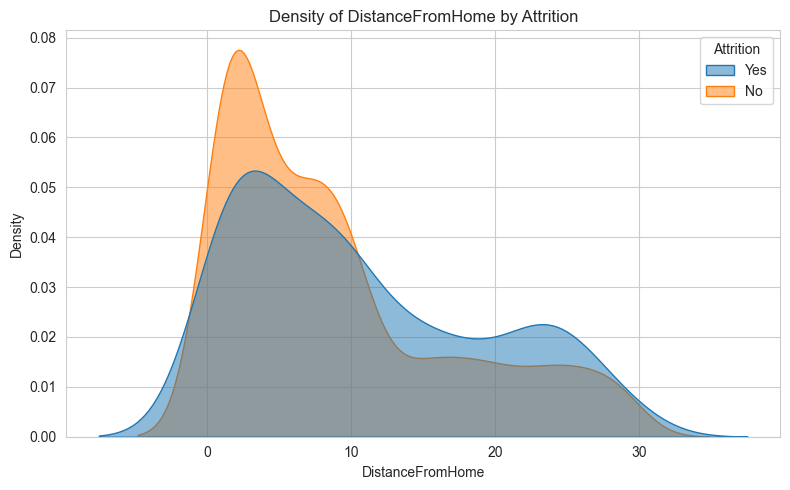

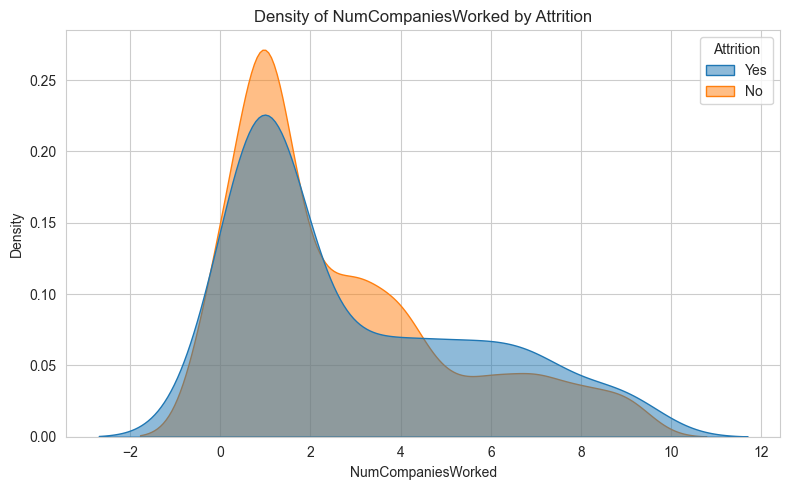

In [12]:
for col in num_features:
    plt.figure(figsize=(8,5))
    sns.kdeplot(data=df_clean, x=col, hue='Attrition', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'Density of {col} by Attrition')
    plt.tight_layout()
    plt.show()

Categorical Features vs Attrition (Grouped Bar Chart)

<Figure size 1000x500 with 0 Axes>

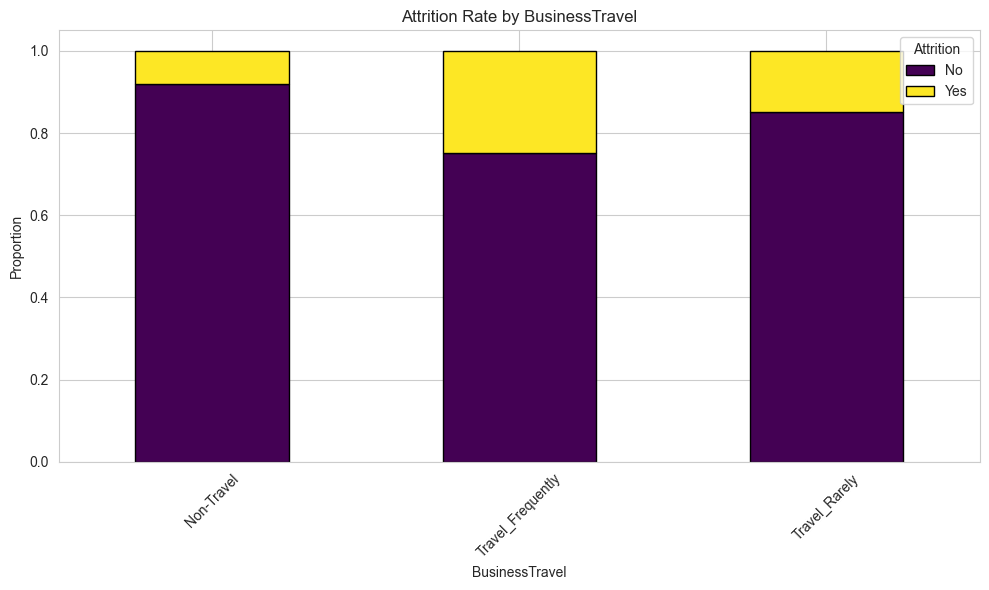

<Figure size 1000x500 with 0 Axes>

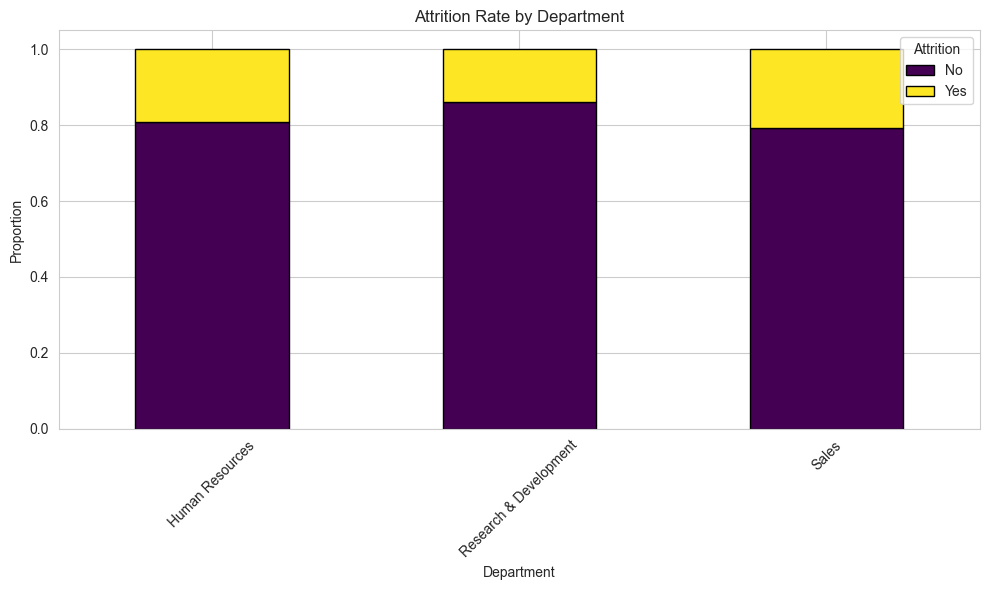

<Figure size 1000x500 with 0 Axes>

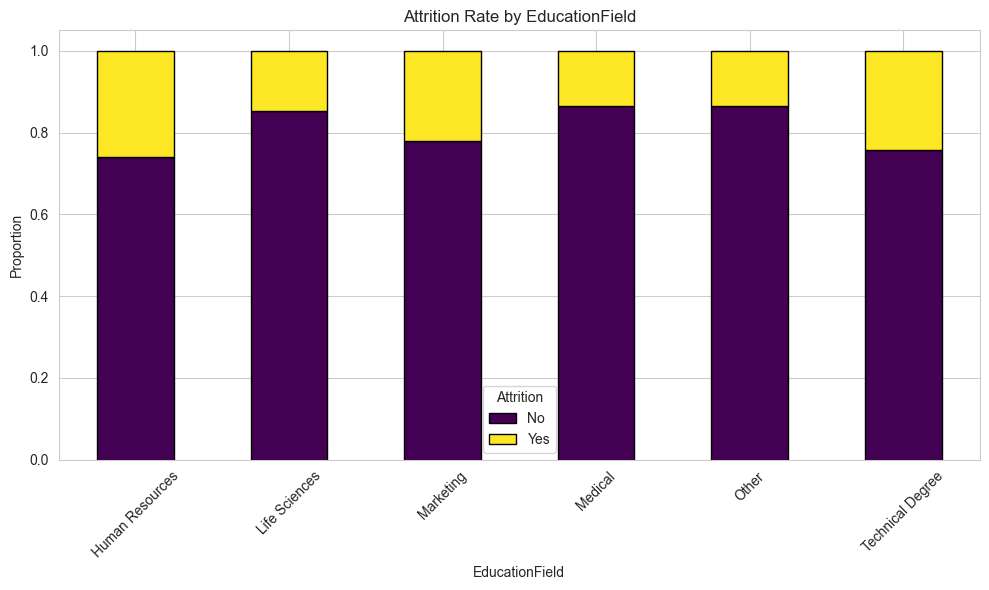

<Figure size 1000x500 with 0 Axes>

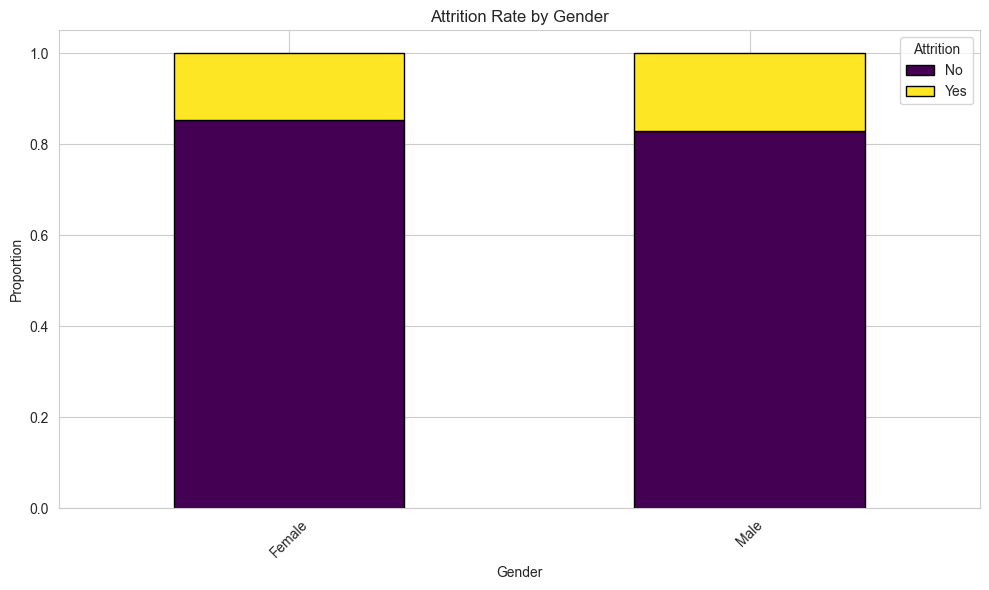

<Figure size 1000x500 with 0 Axes>

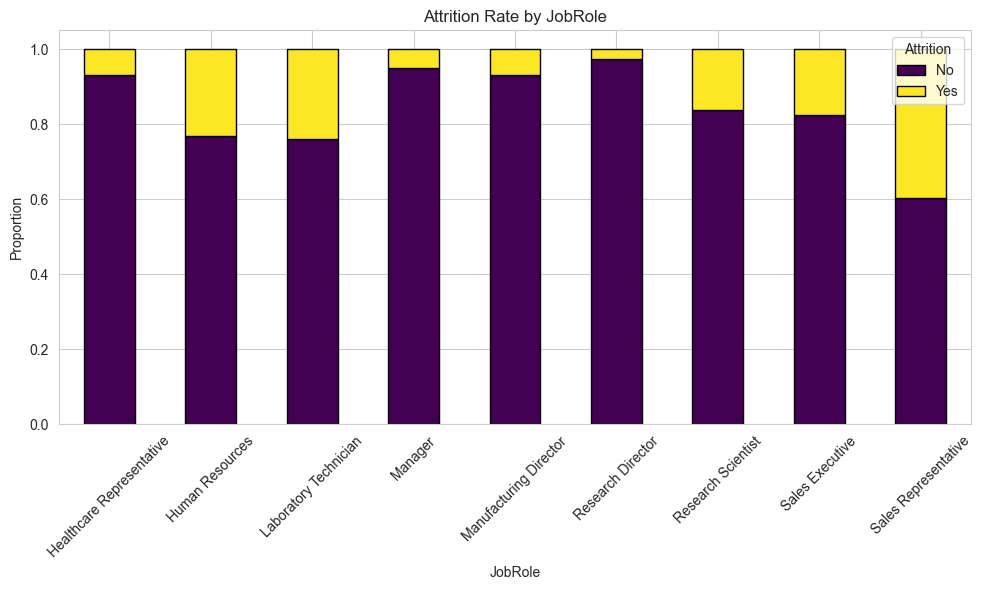

<Figure size 1000x500 with 0 Axes>

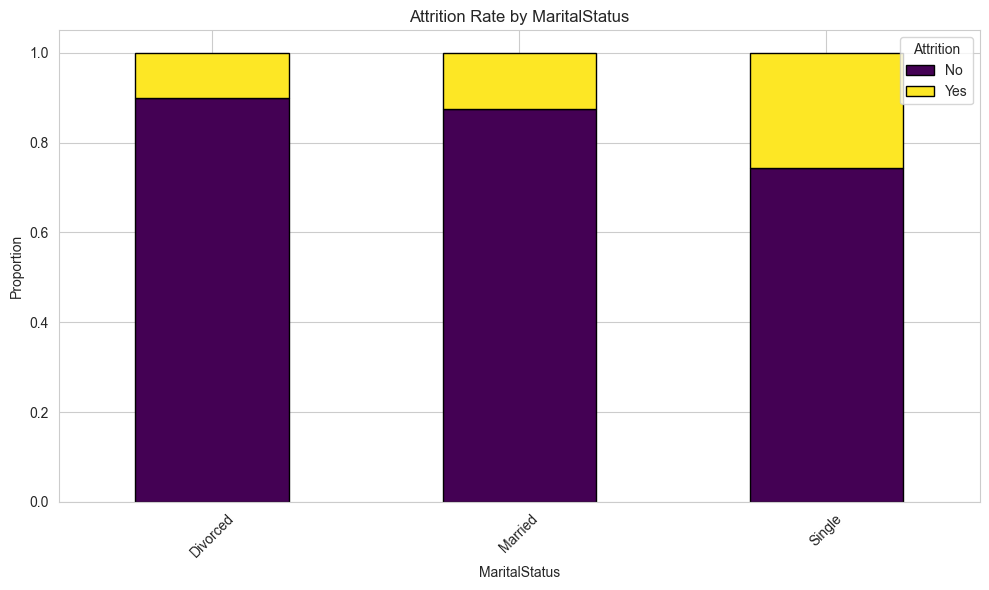

<Figure size 1000x500 with 0 Axes>

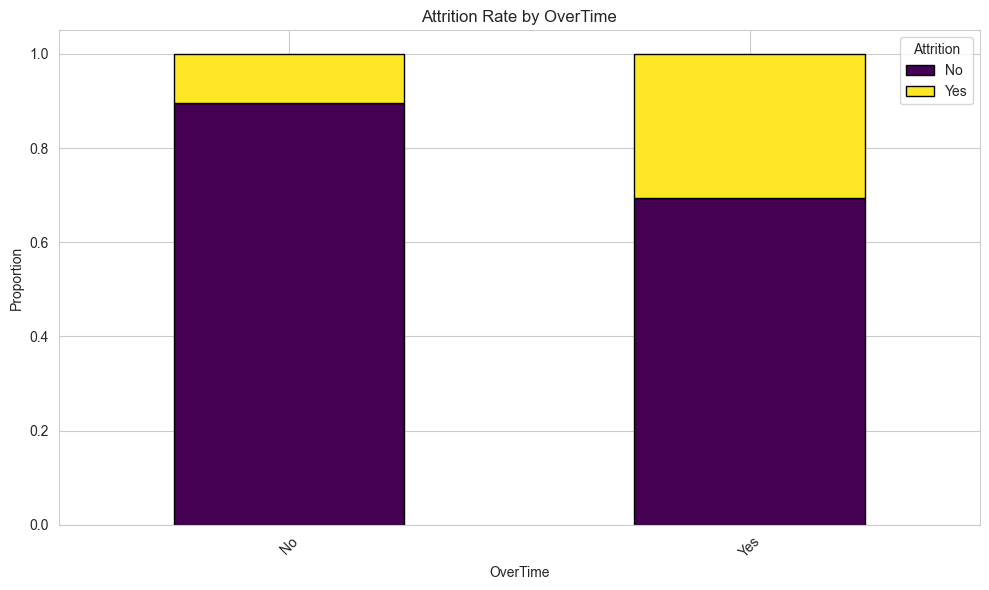

In [13]:
for col in cat_features:
    plt.figure(figsize=(10,5))
    ct = pd.crosstab(df_clean[col], df_clean['Attrition'], normalize='index')
    ct.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black')
    plt.title(f'Attrition Rate by {col}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Attrition')
    plt.tight_layout()
    plt.show()

Correlation Heatmap (Numerical Only)

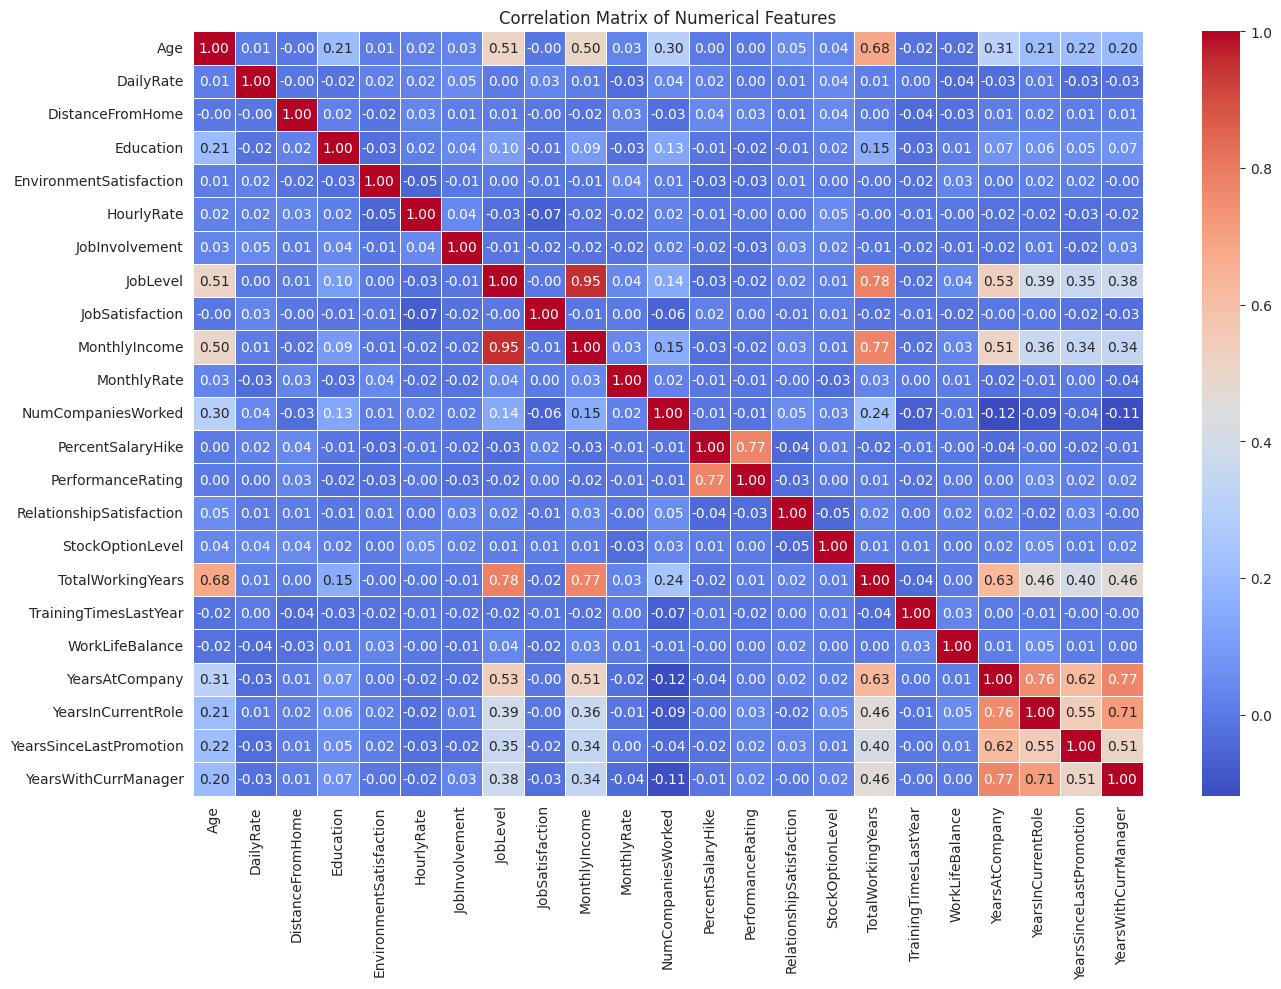

In [12]:
plt.figure(figsize=(14,10))
corr = df_clean[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()

Advanced EDA

Pairplot of top features

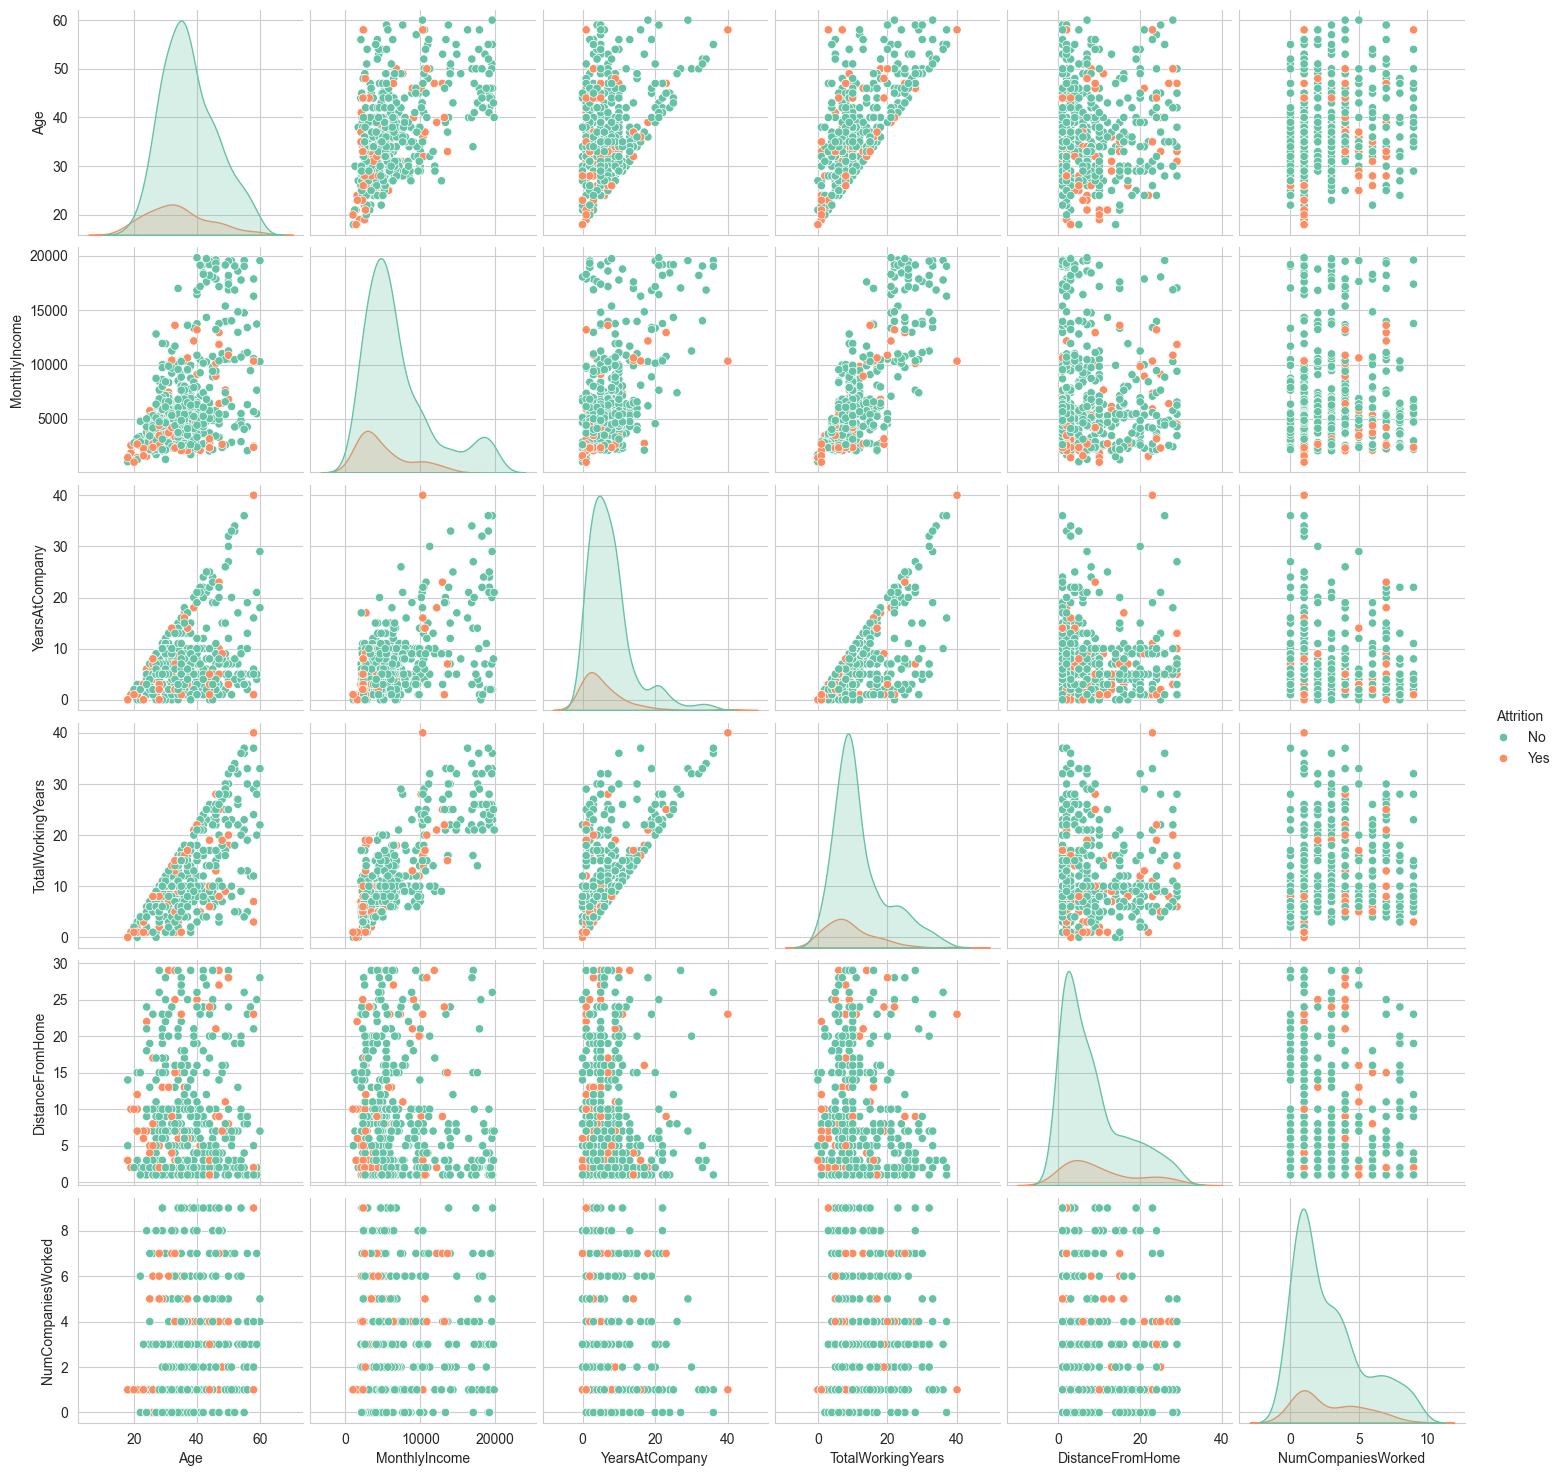

In [14]:
# Sample 500 rows for speed
sample_df = df_clean[num_features + ['Attrition']].sample(500, random_state=42)
sns.pairplot(sample_df, hue='Attrition', palette='Set2', diag_kind='kde')
plt.savefig('pairplot.png', dpi=300)
plt.show()

Feature interactions (e.g., OverTime vs YearsAtCompany)

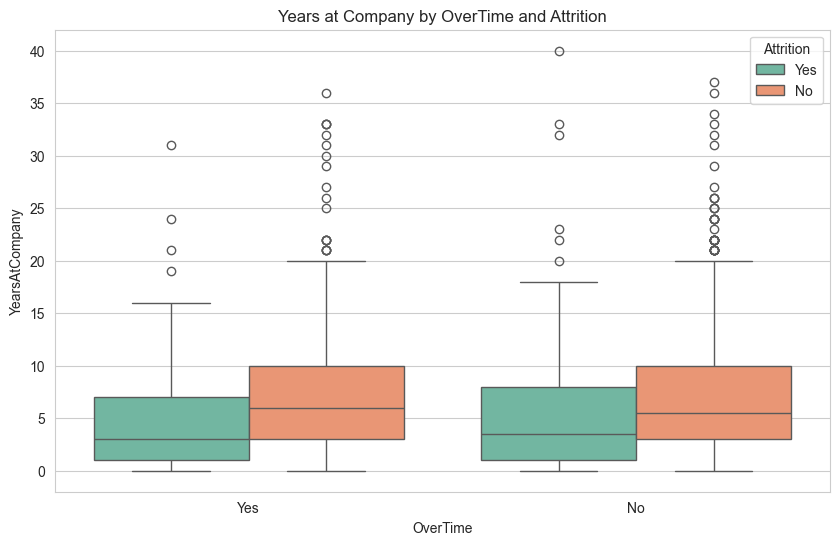

In [15]:
plt.figure(figsize=(10,6))
sns.boxplot(x='OverTime', y='YearsAtCompany', hue='Attrition', data=df_clean, palette='Set2')
plt.title('Years at Company by OverTime and Attrition')
plt.show()

MonthlyIncome by JobRole and Attrition

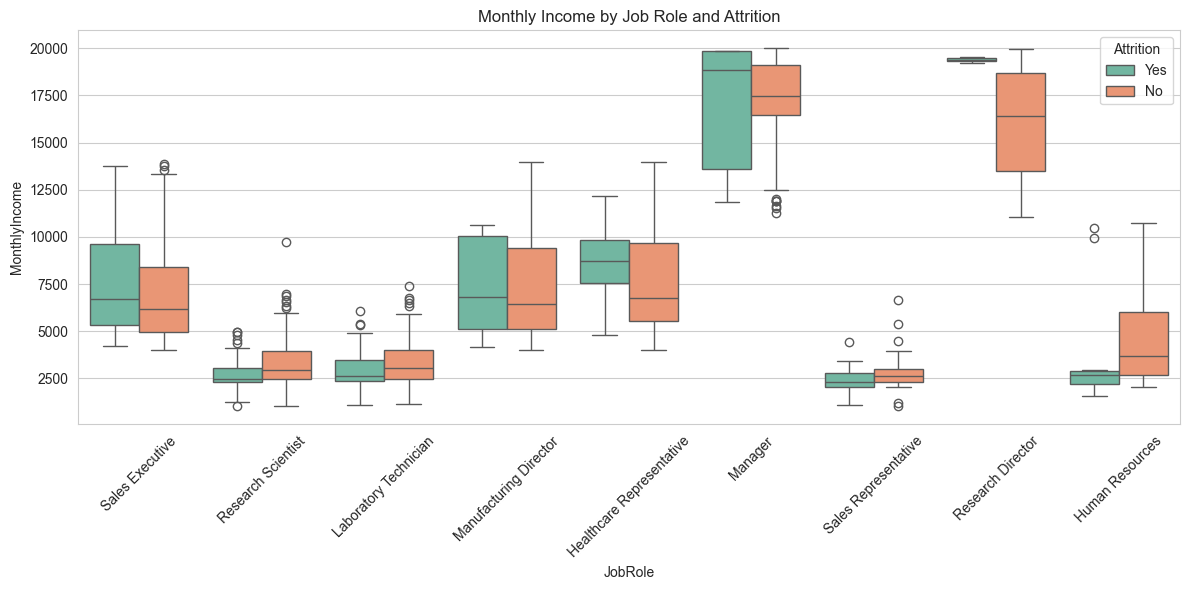

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='JobRole', y='MonthlyIncome', hue='Attrition', data=df_clean, palette='Set2')
plt.xticks(rotation=45)
plt.title('Monthly Income by Job Role and Attrition')
plt.tight_layout()
plt.show()

Data Cleaning

Handle Missing Values

In [17]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Remove Duplicate Rows

In [18]:
df.drop_duplicates(inplace=True)

Drop Unnecessary Columns

In [19]:
df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

Data Preprocessing

In [20]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

Encode categorical variables

In [21]:
df = pd.get_dummies(df, drop_first=True)

Separate features and target

In [22]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

Feature scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
print("Final shape:", X_scaled.shape)

Final shape: (1470, 44)


In [8]:
import os

output_dir = r"C:\Users\DELL\Desktop\new project\xgboost-vs-randomforest-attrition\data\processed"
os.makedirs(output_dir, exist_ok=True)
output_df = df_clean if "df_clean" in globals() else df
output_df.to_csv(os.path.join(output_dir, "cleaned_dataset.csv"), index=False)

# New section